In [2]:
using Revise
using Random
using CairoMakie
using LinearAlgebra
using StatsBase, Distributions
using LaTeXStrings
using DifferentialEquations
using JLD2
includet("Utils.jl")
using .Utils
includet("FigureStyles.jl")
using .FigureStyles
set_theme!(MyTheme)
BLAS.set_num_threads(4)

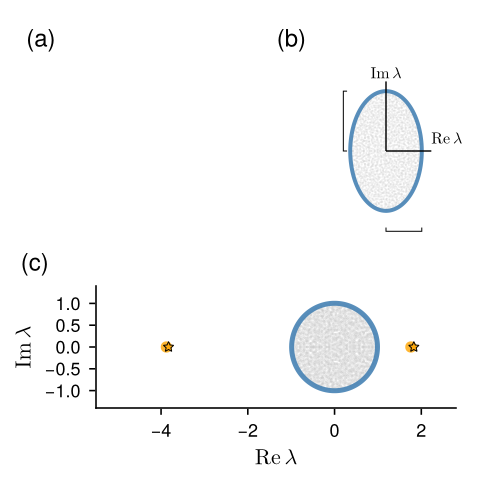

CairoMakie.Screen{IMAGE}


In [ ]:
set_theme!(SingleColumnTheme)
f1 = Figure(size=(3.35*72, 3.4*72), figure_padding=(2.0, 8.0, 1.0, 1.0))

Row1Grid = f1[1, 1:3] = GridLayout()
Label(Row1Grid[1, 1:2, TopLeft()], "(a)", fontsize=12, padding=(0f0, 15f0, 0f0, 0f0))
N = 2000
g = 1.0
J0 = 0.0
τc = 0.1
J = CreateJ(N, J0, g, (τc, 0.0))
A = 1-2*abs(τc)
B = -2τc
λ = eigvals(J)
xlim = 1.5
ylim = 1.7
ax = Axis(Row1Grid[1, 3],
    limits=(-xlim, xlim, -ylim, ylim),
    aspect = xlim/ylim)
Label(Row1Grid[1, 3, TopLeft()], "(b)", fontsize=12, padding=(0f0, 0f0, 0f0, 0f0))
hidedecorations!(ax)
hidespines!(ax)
rowsize!(Row1Grid, 1, Fixed(100))
colsize!(Row1Grid, 3, Fixed(80))
scatter!(ax, real(λ), imag(λ); alpha=0.2, color=:gray70, markersize=1.5, rasterize=10)
θ = range(0, 2π, 200)
lines!(ax, g * (A+B) / sqrt(A) * cos.(θ),
    g * (A-B) / sqrt(A) * sin.(θ), linewidth=2.0, color=:steelblue, alpha=0.9)
long_semiaxis = g * (A+B) / sqrt(A)
short_semiaxis = g * (A-B) / sqrt(A)
axis_line_color = (:black, 0.9)
lines!(ax, [0.0, 0.85], [0.0, 0.0]; color=axis_line_color, linewidth=0.8)
lines!(ax, [0.0, 0.0], [0.0, 1.3]; color=axis_line_color, linewidth=0.8)
text!(ax, 0.85, 0.08; text=L"$\mathrm{Re}\,\lambda$", align=(:left, :bottom), fontsize=8)
text!(ax, 0.0, 1.3; text=L"$\mathrm{Im}\,\lambda$", align=(:center, :bottom), fontsize=8)
long_annotation_y = -1.5
short_annotation_x = -0.8
tick_length = 0.07
lines!(ax, [0.0, 0.0, long_semiaxis, long_semiaxis],
    [long_annotation_y + tick_length, long_annotation_y, long_annotation_y, long_annotation_y + tick_length]; color=:black, linewidth=0.5)
lines!(ax, [short_annotation_x + tick_length, short_annotation_x, short_annotation_x, short_annotation_x + tick_length],
    [0.0, 0.0, short_semiaxis, short_semiaxis]; color=:black, linewidth=0.5)
# text!(ax, long_semiaxis / 2, long_annotation_y - 0.08; text=L"$\frac{A+B}{\sqrt{A}}g$", align=(:center, :top), fontsize=6)
# text!(ax, short_annotation_x - 0.08, short_semiaxis / 2; text=L"$\frac{A-B}{\sqrt{A}}g$", align=(:right, :center), fontsize=6)

N = 2000
g = 1.0
J0 = -2.0 / N
τc = 7.0 / N
A = 1-2*abs(τc)
B = -2τc
J = CreateJ(N, J0, g, (τc, 0.0))
λ = eigvals(J)
bulk = λ[2:end-1]
outlier = λ[[1, N]];
xmin = -5.5; xmax = 2.8; ymax = 1.4; ymin = -1.4
ax = Axis(f1[2, 1:3], limits=(xmin, xmax, ymin, ymax), xlabel=L"$\mathrm{Re}\,\lambda$",
 ylabel = L"$\mathrm{Im}\,\lambda$", aspect = (xmax-xmin)/(ymax-ymin))
Label(f1[2, 1:2, TopLeft()], "(c)", fontsize=12, padding=(0f0, 10f0, 5f0, 0f0))
scatter!(ax, real(bulk), imag(bulk); alpha=0.2, color=:gray70, markersize=2.0, rasterize=10)
scatter!(ax, real(outlier), imag(outlier); alpha = 0.8, color = :orange, markersize=8)
theory_outliers = collect(TheoryOutlier(N, J0, g, (τc, 0.0)))
scatter!(ax, real.(theory_outliers), imag.(theory_outliers); marker=:star5, markersize=6, color=:orange, strokecolor=:black, strokewidth=0.5, alpha=0.8)
lines!(ax, g * (A+B) / sqrt(A) * cos.(θ),
    g * (A-B) / sqrt(A) * sin.(θ), linewidth=2.5, color=:steelblue, alpha=0.9)
rowsize!(f1.layout, 2, Relative(1/3))
rowgap!(f1.layout, -2)
display(f1)
# save("./images/ChainBulkOutlier.pdf",f1, pt_per_unit=1)

## The eigenspectrum of the Jacobian at the a ferromagnetic fixed point

In [3]:
# Run JacBoundary.jl
data = load("results/FPStatisticsJacobianBoundary.jld2")
τrec_vec = data["τrec_vec"]
τchn = data["τchn"]
x_fp_by_τrec = data["x_fp_by_τrec"]
boundary_x_by_τrec = data["boundary_x_by_τrec"]
boundary_y_by_τrec = data["boundary_y_by_τrec"]
eigenvalues_by_τrec = data["eigenvalues_by_τrec"]
x_grid = data["x_grid"]
theory_p_fp_by_τrec = data["theory_p_fp_by_τrec"]
N = data["N"];

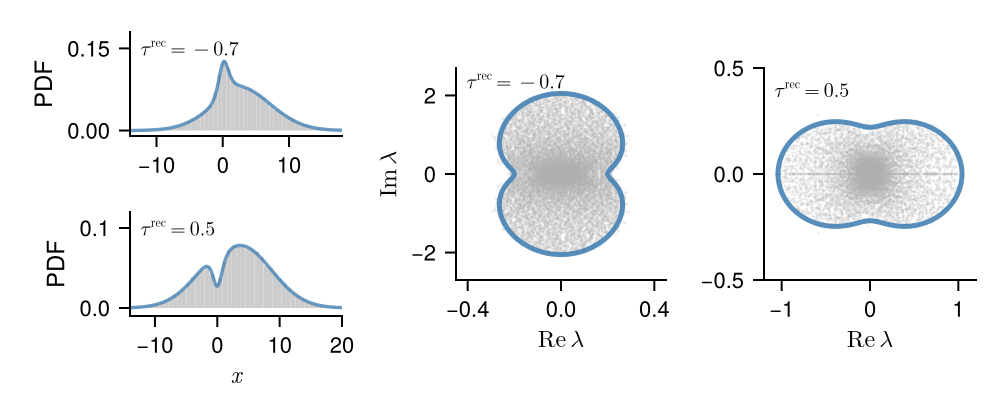

CairoMakie.Screen{IMAGE}


In [9]:
set_theme!(DoubleColumnTheme)
f4 = Figure(size=(7*72, 2.9*72))
ax1 = Axis(f4[1, 1], ylabel="PDF", limits=(-14, 18, -0.01, 0.18), yticks=[0.0, 0.15])
hist!(ax1, x_fp_by_τrec[1]; bins=60, normalization=:pdf, color=:gray80)
lines!(ax1, x_grid, theory_p_fp_by_τrec[1]; linewidth=1.7, color=:steelblue, alpha=0.8)
text!(ax1, 0.05, 0.95; text=L"$\tau^{\mathrm{rec}} = %$(τrec_vec[1])$", space=:relative,
    align=(:left, :top), fontsize=10)

ax2 = Axis(f4[2, 1], xlabel=L"x", ylabel="PDF",  limits=(-14, 20, -0.01, 0.12),
    yticks=[0.0, 0.1])

hist!(ax2, x_fp_by_τrec[2]; bins=60, normalization=:pdf, color=:gray80)
lines!(ax2, x_grid, theory_p_fp_by_τrec[2]; linewidth=1.7, color=:steelblue, alpha=0.8)
text!(ax2, 0.05, 0.95; text=L"$\tau^{\mathrm{rec}} = %$(τrec_vec[2])$", space=:relative,
    align=(:left, :top), fontsize=10)

ax3 = Axis(f4[:, 2], xlabel=L"$\mathrm{Re}\,\lambda$", ylabel=L"$\mathrm{Im}\,\lambda$",
    aspect=1, limits=(-0.45, 0.45, -2.7, 2.7), xticks = [-0.4, 0.0, 0.4], yticks=[-2.0, 0.0, 2.0])
scatter!(ax3, real(eigenvalues_by_τrec[1]), imag(eigenvalues_by_τrec[1]); color=:gray70, 
        alpha=0.2, markersize=2, rasterize=10)
lines!(ax3, boundary_x_by_τrec[1], boundary_y_by_τrec[1]; color=:steelblue, linewidth=2.5, alpha=0.9)
text!(ax3, 0.05, 0.99; text=L"$\tau^{\mathrm{rec}} = %$(τrec_vec[1])$", space=:relative,
    align=(:left, :top), fontsize=10)

ax4 = Axis(f4[:, 3], xlabel=L"$\mathrm{Re}\,\lambda$",
    aspect=1, limits=(-1.2, 1.2, -0.5, 0.5), xticks=[-1.0, 0.0, 1.0])
scatter!(ax4, real(eigenvalues_by_τrec[2]), imag(eigenvalues_by_τrec[2]); color=:gray70, 
        alpha=0.2, markersize=2, rasterize=10)
lines!(ax4, boundary_x_by_τrec[2], boundary_y_by_τrec[2]; color=:steelblue, linewidth=2.5, alpha=0.9)
text!(ax4, 0.05, 0.95; text=L"$\tau^{\mathrm{rec}} = %$(τrec_vec[2])$", space=:relative,
    align=(:left, :top), fontsize=10)
# save("images/FPStatisticsJacobianBoundary.pdf", f4, pt_per_unit=1)
display(f4)